In [1]:
import pulser
from pulser import Register, Sequence
from pulser.devices import MockDevice
from pulser.pulse import Pulse
from pulser.waveforms import RampWaveform, ConstantWaveform
from pulser.backend import BitStrings
from pulser_simulation import QutipConfig

import numpy as np
import json
import yaml
from pathlib import Path
import matplotlib.pyplot as plt

from pasqal_cloud import SDK
from pasqal_cloud.device import DeviceTypeName, EmuTNConfig


C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\pulser\register\register.py:58: DeprecationWarning: Usage of `int`s or any non-`str`types as `QubitId`s will be deprecated. Define your `QubitId`s as `str`s, prefer setting `prefix='q'` when using classmethods, as that will become the new default once `int` qubit IDs become invalid.
  super().__init__(qubits, **kwargs)


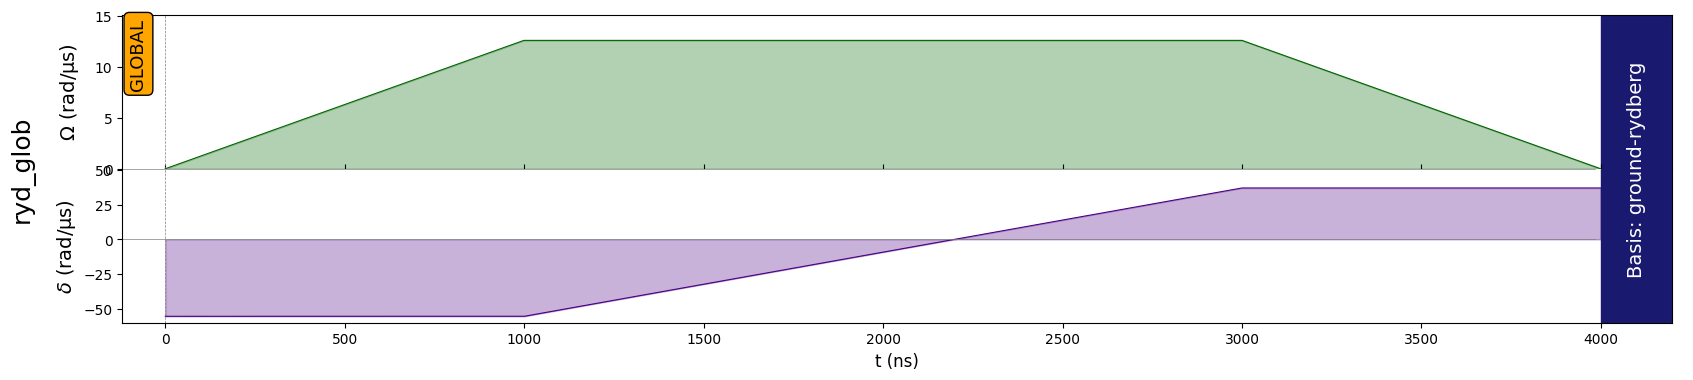

In [2]:
from pulser import Register, Sequence, Pulse
from pulser.devices import MockDevice
from pulser.waveforms import RampWaveform, ConstantWaveform, CompositeWaveform
import numpy as np

# ── REGISTER: 4×4 square lattice, 6 µm spacing ──────────────────
reg = Register.square(4, spacing=6.0)

# ── SEQUENCE ─────────────────────────────────────────────────────
seq = Sequence(reg, MockDevice)
seq.declare_channel("ryd_glob", "rydberg_global")

# ── PARAMETERS ───────────────────────────────────────────────────
U     = 862690 / 6.0**6      # NN interaction ≈ 66 rad/µs
Omega = 2 * np.pi * 2.0      # Rabi frequency ≈ 12.6 rad/µs
t_ramp = 1000                # ns
t_hold = 2000                # ns
delta_i = -3 * U             # start: all atoms in |g⟩
delta_f =  2 * U             # end: AFM ordered phase

# ── PULSE: 3-stage adiabatic sweep ───────────────────────────────
amp_wf = CompositeWaveform(
    RampWaveform(t_ramp, 0,     Omega),
    ConstantWaveform(t_hold,    Omega),
    RampWaveform(t_ramp, Omega, 0    )
)
det_wf = CompositeWaveform(
    ConstantWaveform(t_ramp,       delta_i),
    RampWaveform(t_hold, delta_i,  delta_f),
    ConstantWaveform(t_ramp,       delta_f)
)

seq.add(Pulse(amp_wf, det_wf, phase=0), "ryd_glob")
seq.measure("ground-rydberg")
seq.draw()

In [8]:
import pulser
# Manually generate the IDs and coordinates of a 2x2 square with 5μm spacing
# qubits = {"q0": [0, 1], "q1": [5, 0], "q2": [0, 5], "q3": [5, 5]}
reg = pulser.Register.from_coordinates([[0,0], [5,0], [0,5], [5,5]],prefix="q")
print(reg.qubits)

{'q0': array([-2.5, -2.5]), 'q1': array([ 2.5, -2.5]), 'q2': array([-2.5,  2.5]), 'q3': array([2.5, 2.5])}


This notebook demonstrates the use of the Pulser library for simulating quantum annealing in a square array of Rydberg atoms. It focuses on two emulator backends available in Pulser, QUTIP and EMU_MPS, and provides examples of how to run MPS-based simulations in the cloud.

For more information about Pulser, visit their official documentation:https://pulser.readthedocs.io/en/stable/index.html

In [2]:
#List of functions that are used in the simulations

def central_normalized_interaction(L):
    c = L // 2
    interaction = 0.0

    for i in range(L):
        for j in range(L):
            if i == c and j == c:
                continue
            dx = i - c
            dy = j - c
            interaction += 1.0 / ((dx*dx + dy*dy)**3)

    return interaction

def array_of_bitstrings(results):
    samples = []
    for b, n in results[0].items():
        z = 2 * np.array([int(x) for x in b]) - 1
        samples.extend([z] * n)
    samples = np.array(samples)
    return samples


def af_structure_factor(bitstrings, L):
    N = L * L
    shots = sum(bitstrings.values())

    samples = []
    for b, n in bitstrings.items():
        z = 2 * np.array([int(x) for x in b]) - 1
        samples.extend([z] * n)

    samples = np.array(samples)
    connected = samples.T @ samples / shots - np.outer(samples.mean(0), samples.mean(0))

    stagger = np.array([(-1)**(i+j) for i in range(L) for j in range(L)])

    return stagger @ connected @ stagger / (N**2)

def build_afm_sequence(Omega_max,t_ramp,t_hold,t_fall,Delta0,Delta1,device,reg):
    seq = Sequence(reg, device)
    seq.declare_channel("rydberg_global", "rydberg_global")
    seq.add(Pulse(RampWaveform(t_ramp, 0, Omega_max),ConstantWaveform(t_ramp, Delta0),0),"rydberg_global")
    seq.add(Pulse(ConstantWaveform(t_hold, Omega_max),RampWaveform(t_hold, Delta0,Delta1),0),"rydberg_global")
    seq.add(Pulse(RampWaveform(t_fall, Omega_max, 0),ConstantWaveform(t_fall, Delta1),0),"rydberg_global")
    return seq

def load_pasqal_config(path):
    with open(path, "r") as f:
        return yaml.safe_load(f)


def submit_afm_batch(seq, run_name, config_file, runs, dt, chi_max):
    config = load_pasqal_config(config_file)

    sdk = SDK(username=config["username"],project_id=config["project_id"],password=config["password"])

    batch = sdk.create_batch(seq.to_abstract_repr(), [{"runs": runs, "variables": {}}],device_type=DeviceTypeName.EMU_MPS,
                             configuration=EmuTNConfig(dt=dt, max_bond_dim=chi_max))

    file = Path("saved_batches.json")
    saved = json.loads(file.read_text()) if file.exists() else {}
    saved[run_name] = batch.id

    file.write_text(json.dumps(saved, indent=4))

    return batch


def retrieve_batch(run_name, config_file, saved_file="saved_batches.json"):
    config = load_pasqal_config(config_file)

    with open(saved_file, "r") as f:
        batch_id = json.load(f)[run_name]

    sdk = SDK(username=config["username"],project_id=config["project_id"],password=config["password"])
    
    batch = sdk.get_batch(batch_id)
    return batch, [job.result for job in batch.ordered_jobs]



In [8]:
#Defining parameters for the register and pulse sequence
L = 4
Omega_max = 2.0*np.pi*2.0
Omega_over_U = 1.3
U = Omega_max / Omega_over_U
Delta0 = -3 * U
Delta1 = central_normalized_interaction(L)/2 * U

t_ramp = 1000
t_hold = 1000
t_fall = 2000

# Define the number of runs and simulation time step
n_runs = 1000
dt = 10

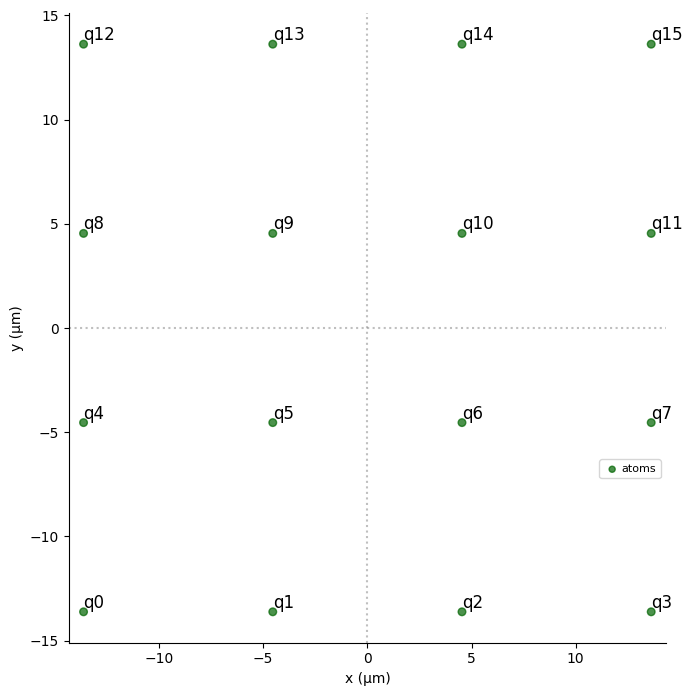

In [4]:
###### Set up the device and register
device = MockDevice

###### This part defines the Register (i.e, the relative positions of the atoms involved in the computation)
spacing = device.rydberg_blockade_radius(U)
reg = Register.square(L, spacing, prefix="q")
reg.draw()

Register({'q0': array([-16.5       , -12.99038106]), 'q1': array([-10.5       , -12.99038106]), 'q2': array([ -4.5       , -12.99038106]), 'q3': array([  1.5       , -12.99038106]), 'q4': array([  7.5       , -12.99038106]), 'q5': array([ 13.5       , -12.99038106]), 'q6': array([-13.5       ,  -7.79422863]), 'q7': array([-7.5       , -7.79422863]), 'q8': array([-1.5       , -7.79422863]), 'q9': array([ 4.5       , -7.79422863]), 'q10': array([10.5       , -7.79422863]), 'q11': array([16.5       , -7.79422863]), 'q12': array([-16.5       ,  -2.59807621]), 'q13': array([-10.5       ,  -2.59807621]), 'q14': array([-4.5       , -2.59807621]), 'q15': array([ 1.5       , -2.59807621]), 'q16': array([ 7.5       , -2.59807621]), 'q17': array([13.5       , -2.59807621]), 'q18': array([-13.5       ,   2.59807621]), 'q19': array([-7.5       ,  2.59807621]), 'q20': array([-1.5       ,  2.59807621]), 'q21': array([4.5       , 2.59807621]), 'q22': array([10.5       ,  2.59807621]), 'q23': array([16

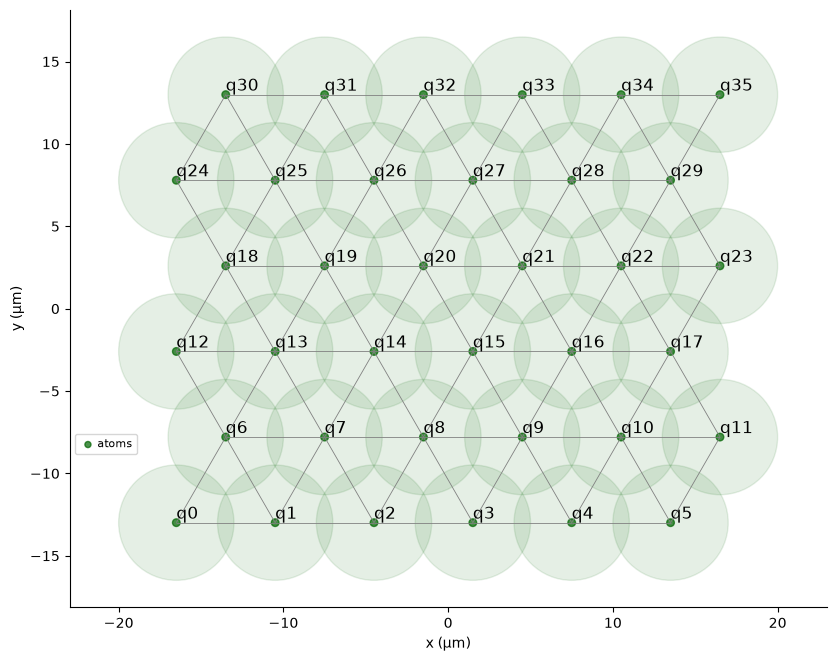

In [2]:
from pulser import Register

triangular_reg = Register.triangular_lattice(rows=6, atoms_per_row=6, spacing=6.0, prefix="q")
print(triangular_reg)

triangular_reg.draw(
    blockade_radius=7,
    draw_half_radius=True,
    draw_graph=True
)

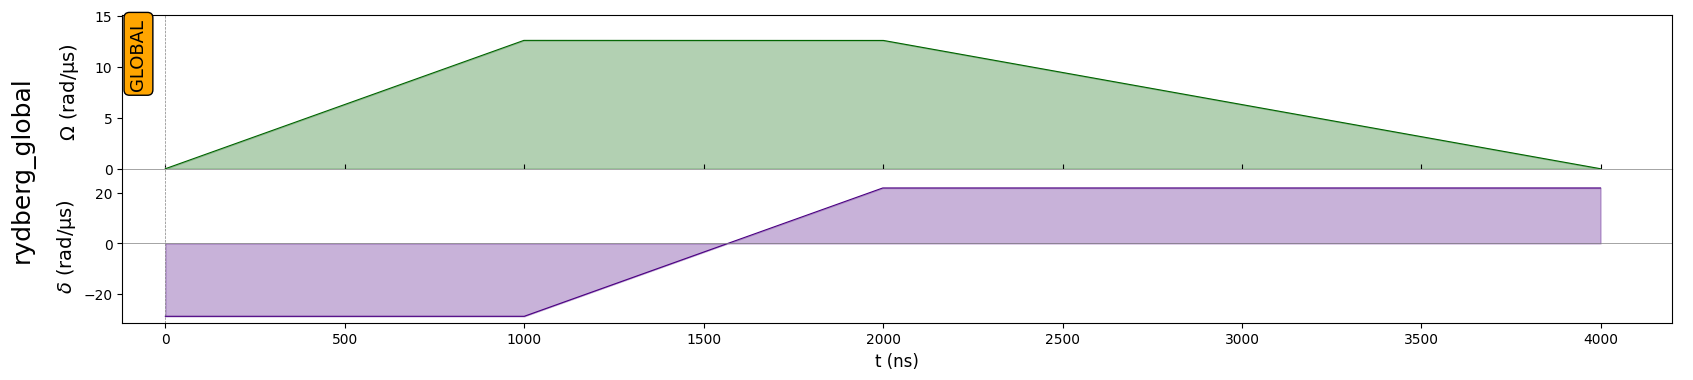

In [5]:
##### Build the time sequences for the AFM preparation experiment
seq = build_afm_sequence(Omega_max=Omega_max,t_ramp=t_ramp,t_hold=t_hold,t_fall=t_fall,Delta0=Delta0,Delta1=Delta1,device=device,reg=reg)
seq.draw()

Text(0, 0.5, 'AFM Structure Factor')

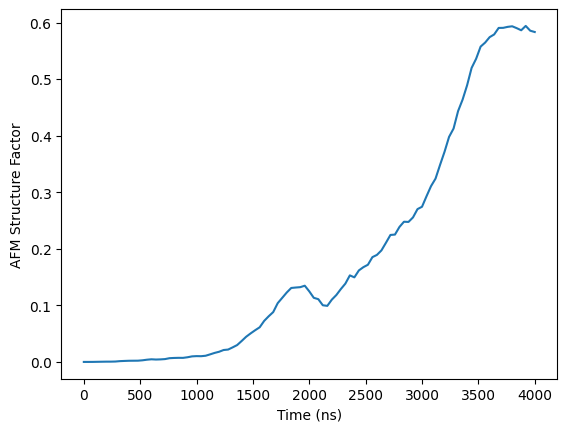

In [6]:
#Run the emulator  in a local device using a Backend based on Qutip
#As an example it beasure bitstrings at different time of the sequence and compute the AFM structure factor

# Relative times in the sequence (0 = start, 1 = end)
eval_times = np.arange(0.0, 1.01, 0.01)
T = seq.get_duration()  # ns
physical_times = [t * T for t in eval_times]

config = QutipConfig(observables=( BitStrings(evaluation_times=eval_times,num_shots=4000,),))
qutip_bknd = pulser.backends.QutipBackendV2(seq, config=config)
results = qutip_bknd.run()

#Compute the AFM structure factor at different times in the sequence
list_afm_qutip = []
for t in results.get_result_times("bitstrings"):
    counts = results.get_result("bitstrings", t)
    sf_afm =  af_structure_factor(counts, L)
    list_afm_qutip.append((t * T , sf_afm))
    
plt.plot(*zip(*list_afm_qutip),'-')
plt.xlabel('Time (ns)')
plt.ylabel('AFM Structure Factor')

In [ ]:
#####   Run the sequence  using the Pasqal Cloud API  #########
#See: https://pulser.readthedocs.io/en/stable/tutorials/backends.html#4.-Configuring-the-Emulation

from pulser_pasqal import PasqalCloud
credentials_file = "credentials.example.yaml" # this part has to be changed to include credentials of the participants 
connection = load_pasqal_config(credentials_file)
connection = PasqalCloud(
    username=connection['username'],  # Your username or email address for the Pasqal Cloud Platform
    project_id=connection['project_id'],  # The ID of the project associated to your account
    password=connection['password'],  # The password for your Pasqal Cloud Platform account
)

# Create a batch and submit it to the EmuMPS backend
#See https://pulser.readthedocs.io/en/stable/apidoc/_autosummary/pulser_pasqal.EmuMPSBackend.html#pulser_pasqal.EmuMPSBackend
# Define the number of runs and simulation time step
n_runs = 1000
dt = 10
chi_max = 50 # Bond dimension for the simulation

remote_config = pulser.backend.EmulationConfig(observables=( BitStrings(evaluation_times=eval_times,num_shots=1000,),),
                                               dt=dt, max_bond_dim=chi_max)
mps_bknd = pulser.backends.EmuMPSBackend(seq, config=remote_config, connection=connection)
mps_results = mps_bknd.run()
print(f"Submitted batch {mps_results.batch_id} to EmuMPSBackend")

Submitted batch 9a4e4e7f-b7b8-4dbf-905b-92fd930d643a to EmuMPSBackend


BatchStatus.DONE
Got results: {'87e3005a-6d80-4965-bac4-c5f7162509a8': <pulser.backend.results.Results object at 0x14a572c60>} 



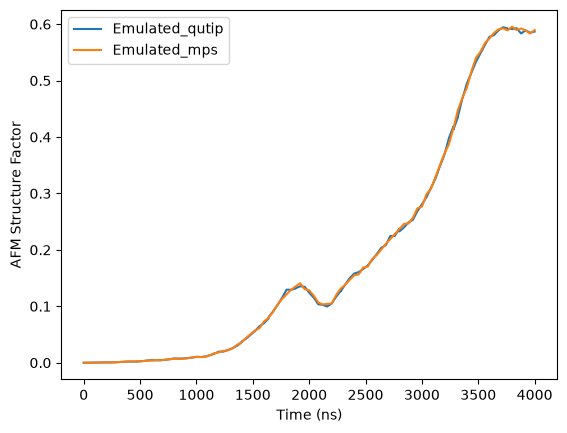

In [36]:
#When the batch states shows as DONE, the results can be accessed.
print(mps_results.get_batch_status()) ## You need to wait for the results to be available before accessing them, i.e., "BatchStatus.DONE"
print("Got results:", mps_results.get_available_results(), "\n")

#Compute the AFM structure factor at different times in the sequence
if mps_results.get_available_results():
    list_afm_mps = []

    for t in mps_results[-1].get_result_times("bitstrings"):
        counts = mps_results[-1].get_result("bitstrings", t)
        sf_afm =  af_structure_factor(counts, L)
        list_afm_mps.append((t * T , sf_afm))
        
    plt.plot(*zip(*list_afm_mps),'-',label='Emulated_qutip')
    plt.plot(*zip(*list_afm_qutip),'-',label='Emulated_mps')
    plt.legend(loc='best')
    plt.xlabel('Time (ns)')
    plt.ylabel('AFM Structure Factor')


In [393]:
#####   Run the simulations using the Pasqal Cloud API  #########
# This is an alternative to running the sequence in the cloud using MPS backend.
# Define the number of runs and simulation time step
n_runs = 1000
dt = 10
# Bond dimension for the simulation
chi_max = 50

credentials_file = "credentials.yaml" # this part has to be changed to include credentials of participants of Hackaton
run_name = "Test_AFM"

# Run simulations
batch = submit_afm_batch(seq,run_name=run_name,config_file=credentials_file,runs=n_runs,dt=dt,chi_max=chi_max)
# Retrieve the results from the Cloud API
batch, results = retrieve_batch(run_name=run_name,config_file=credentials_file)
#print(array_of_bitstrings(results))

AttributeError: 'NoneType' object has no attribute 'items'